📊 Telco Customer Churn Prediction

🎯 Objective:
To predict whether a customer will churn based on their service usage,
contract type, and billing information.

💼 Business Impact:
Reducing churn helps telecom companies retain customers and increase revenue.

📌 Approach:
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building (Multiple Models)
- Model Evaluation & Comparison

📊 Step 1: Initialize Spark Session

In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder.appName("VSCode_PySpark").getOrCreate()

 📂 Step 2: Load Dataset


In [42]:
#Loading Telco Customer Churn dataset
# header=True → first row contains column names
# inferSchema=True → automatically detects data types

df = spark.read.csv("telco-churn.csv",header=True,inferSchema=True)

👀 Step 3: Preview Data

In [4]:
df.show(10)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [44]:
# Count number of rows and columns
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 7043
Number of columns: 21


🧠 Step 4: Understand Schema

In [43]:
# Shows column names and data types
df.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)



# 🧹 Data Cleaning & Preprocessing

🔍 Step 1: Identify Blank Values in String Columns

In [ ]:

from pyspark.sql import functions as F

# Extract all string columns
string_cols = [c for c, t in df.dtypes if t == "string"]

# Count blank values in each column
blank_counts = df.select([
    F.sum(
        F.when(F.trim(F.col(c)) == "", 1).otherwise(0)
    ).alias(c)
    for c in string_cols
])

blank_counts.show(truncate=False)

+----------+------+-------+----------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+------------+-----+
|customerID|gender|Partner|Dependents|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|TotalCharges|Churn|
+----------+------+-------+----------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+------------+-----+
|0         |0     |0      |0         |0           |0            |0              |0             |0           |0               |0          |0          |0              |0       |0               |0            |11          |0    |
+----------+------+-------+----------+------------+-------------+---------------+--------------+

We first identify blank (empty string) values in all string columns.

Why?
- Blank values are not treated as NULL automatically
- They can cause errors during type conversion and modeling
- Need to be handled explicitly

🔎 Step 2: Inspect TotalCharges column

In [8]:
df.filter(F.col("TotalCharges")==" ").show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    StreamingMovies|Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------+----------------+--------------------+--------------+------------+-----+
|4472-LVYGI|Female|            0|    Yes|       Yes|     0|          No|No phon

Step 3: Handle missing values

In [46]:
#  Replace blanks with NULL and convert datatype
df = df.withColumn(
    "TotalCharges",
    F.when(F.trim(F.col("TotalCharges")) == "", None)
     .otherwise(F.col("TotalCharges"))
     .cast("double")
)

df.select("TotalCharges").printSchema()

root
 |-- TotalCharges: double (nullable = true)



Step 4: Check missing values

In [10]:
df.select(F.sum(F.col("TotalCharges").isNull().cast("int")).alias("nulls_in_TotalCharges")).show()


+---------------------+
|nulls_in_TotalCharges|
+---------------------+
|                   11|
+---------------------+



Step 5: Impute missing values

In [11]:
mean_total = df.select(F.mean("TotalCharges").alias("m")).first()["m"]

df = df.fillna({"TotalCharges": mean_total})

df.select(F.sum(F.col("TotalCharges").isNull().cast("int")).alias("nulls_in_TotalCharges")).show()


+---------------------+
|nulls_in_TotalCharges|
+---------------------+
|                    0|
+---------------------+



In [12]:
mean_total

2283.3004408418697

Step 6: Check target distribution

In [13]:
churn_counts=df.groupBy("Churn").count()
churn_counts.show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5174|
|  Yes| 1869|
+-----+-----+



In [47]:
# Check skewness
df.select(F.skewness("TotalCharges")).show()

+----------------------+
|skewness(TotalCharges)|
+----------------------+
|    0.9614373590490022|
+----------------------+



Insight:
- The dataset is slightly imbalanced between churned and non-churned customers

Why this matters:
- Imbalanced data can affect model performance
- May require techniques like resampling or class weighting

## 📊 Exploratory Data Analysis (EDA)

In [14]:
!pip install matplotlib
!pip install pandas
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 📌 Churn Distribution

This plot shows the number of customers who churned vs those who stayed.

💡 Insight:
- If classes are imbalanced → model may become biased
- Important to check before training

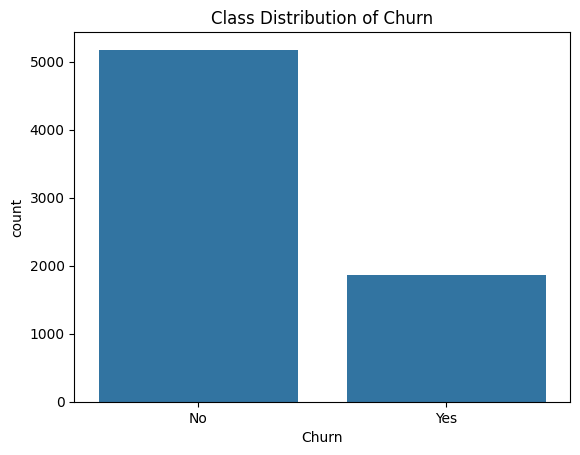

In [48]:
# This plot shows the number of customers who churned vs those who stayed.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


churn_pd = churn_counts.toPandas()
sns.barplot(data=churn_pd, x="Churn", y="count")
plt.title("Class Distribution of Churn")
plt.show()

### 📌 Numerical Feature Distribution

Boxplots help identify:
- Outliers
- Spread of data
- Skewness

💡 Insights:

🔹 Tenure:
- Customers with low tenure → more likely to churn
- Long-term customers are more stable

🔹 Monthly Charges:
- Higher charges may lead to higher churn

🔹 Total Charges:
- Reflects customer lifetime value

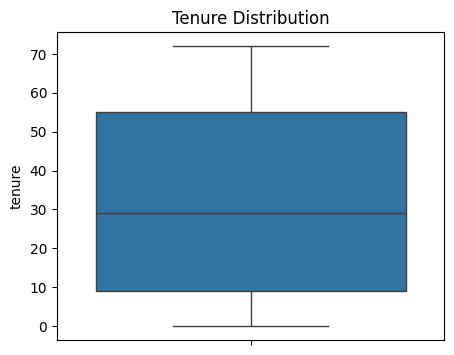

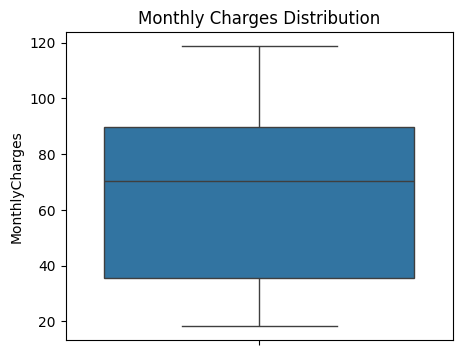

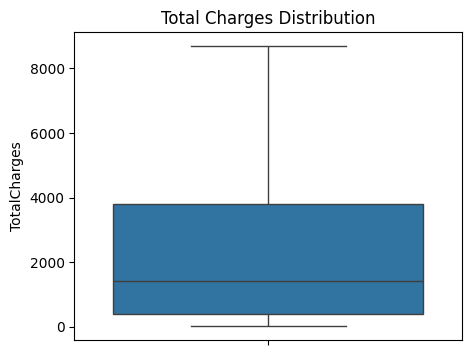

In [16]:
num_df = df.select("tenure", "MonthlyCharges", "TotalCharges")

num_pd = num_df.toPandas()

plt.figure(figsize=(5,4))
sns.boxplot(y=num_pd["tenure"])
plt.title("Tenure Distribution")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=num_pd["MonthlyCharges"])
plt.title("Monthly Charges Distribution")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=num_pd["TotalCharges"])
plt.title("Total Charges Distribution")
plt.show()

### 📌 Monthly Charges vs Churn
This visualization compares distribution of monthly charges across churn categories.

💡 Insight:
- Customers with higher monthly charges show higher churn tendency
- Pricing plays a key role in customer retention

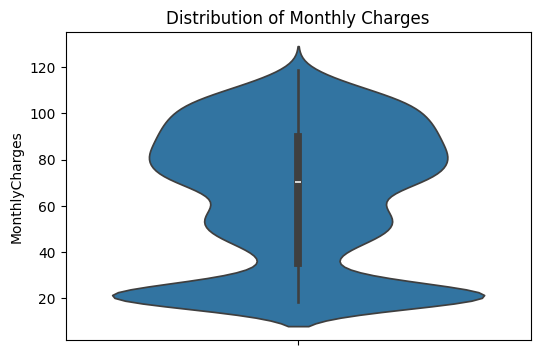

In [17]:
plt.figure(figsize=(6,4))
sns.violinplot(y=num_pd["MonthlyCharges"])
plt.title("Distribution of Monthly Charges")
plt.show()

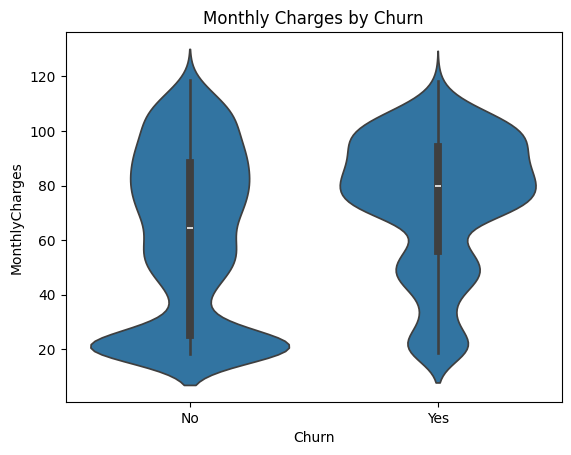

In [18]:
violin_pd = df.select("Churn", "MonthlyCharges").toPandas()

sns.violinplot(data=violin_pd, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

### 📌 Distribution of Monthly Charges

Histogram shows frequency distribution of charges.

💡 Insight:
- Helps understand customer pricing segments
- Can identify clusters of low vs high paying customers

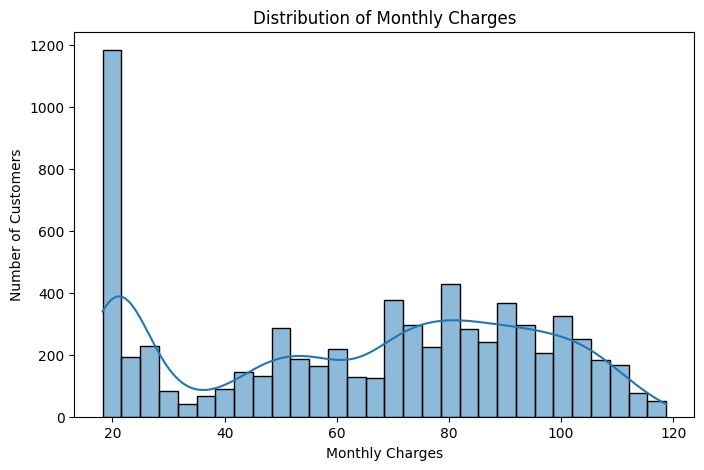

In [19]:
monthly_pd = df.select("MonthlyCharges").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(monthly_pd["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

### 📌 Monthly Charges Distribution by Churn

This is one of the most important visualizations.

💡 Key Insight:
- Customers with higher monthly charges are more likely to churn
- Clear separation between churned and non-churned customers

📊 Business Meaning:
- High pricing may be a churn driver
- Discounts or retention offers can reduce churn

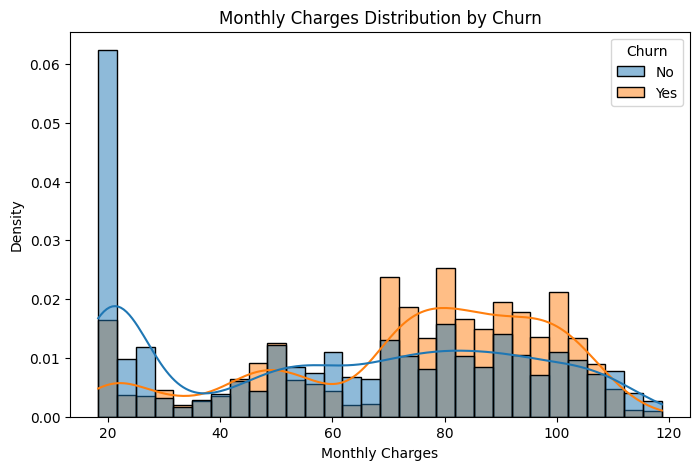

In [20]:
churn_monthly_pd = df.select("Churn", "MonthlyCharges").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(
    data=churn_monthly_pd,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()

💡 Insight:
- Strong correlation between MonthlyCharges and TotalCharges
- Helps in feature selection

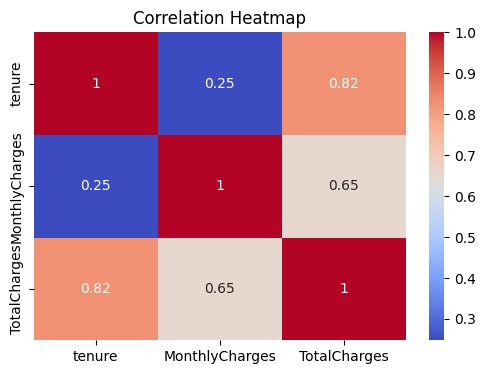

In [49]:
# Correlation Heatmap
corr_pd = num_pd.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_pd, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## ⚙️ Feature Engineering & Transformation Pipeline

In this step, categorical and numerical features are transformed into a format suitable for machine learning models.

### Types of features:

- **Nominal Features** → No order (e.g., gender, payment method)
- **Ordinal Features** → Have order (e.g., contract type)
- **Binary Features** → Yes/No type variables
- **Numerical Features** → Continuous values

A pipeline is used to ensure:
- Reproducibility
- Scalability
- Proper transformation during training and testing

StringIndexer is used to convert categorical variables into numeric indices.

Why needed?
- Machine learning models cannot handle string values
- Converts categories into numerical format

In [22]:
nominal_cols = [
    "gender", "InternetService", "PaymentMethod",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "MultipleLines"
]

ordinal_cols = ["Contract"]

binary_cols = [
    "Partner", "Dependents", "PhoneService",
    "PaperlessBilling"
]

numeric_cols = [
    "SeniorCitizen", "tenure",
    "MonthlyCharges", "TotalCharges"
]

In [ ]:

nominal_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in nominal_cols
]



In [ ]:
ordinal_indexer = StringIndexer(
    inputCol="Contract",
    outputCol="Contract_idx",
    handleInvalid="keep"
)

In [25]:
binary_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in binary_cols
]

OneHotEncoder is used for nominal variables to avoid introducing false order.

In [82]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in nominal_cols] + ["Contract_idx"],
    outputCols=[f"{c}_vec" for c in nominal_cols] + ["Contract_vec"],
    handleInvalid="keep"
)

In [83]:
from pyspark.ml.feature import VectorAssembler

feature_cols = (
    numeric_cols +
    [f"{c}_idx" for c in binary_cols] +
    [f"{c}_vec" for c in nominal_cols] +
    ["Contract_vec"]
)

StandardScaler standardizes numerical features.

Why?
- Ensures all features are on similar scale
- Improves model performance

Note:
withMean=False is used because Spark uses sparse vectors

In [79]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=False,   # IMPORTANT for sparse vectors
    withStd=True
)

In [84]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep"   # 🔥 IMPORTANT
)

In [98]:
from pyspark.ml import Pipeline

stages = []


# 2. Nominal categorical indexers
stages += nominal_indexers

# 3. Binary categorical indexers
stages += binary_indexers

# 4. Ordinal indexer
stages.append(ordinal_indexer)

# 5. One-hot encoder (nominal + Contract)
stages.append(encoder)

stages.append(assembler)

stages.append(scaler)



pipeline = Pipeline(stages=stages)

In [69]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "label",
    when(col("Churn") == "Yes", 1.0).otherwise(0.0)
)

In [70]:
df.select("Churn", "label").show(5)

+-----+-----+
|Churn|label|
+-----+-----+
|   No|  0.0|
|   No|  0.0|
|  Yes|  1.0|
|   No|  0.0|
|  Yes|  1.0|
+-----+-----+
only showing top 5 rows


## 📊 Train-Test Split & Handling Class Imbalance

In [ ]:
# 🧹 Remove unnecessary column
# customerID is just an identifier → not useful for prediction
df = df.drop("customerID")

In [71]:
# 📊 Train-Test Split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)  #random split

print("Train rows:", train_df.count())
print("Test rows :", test_df.count())

Train rows: 5698
Test rows : 1345


The dataset is split into:
- 80% training data
- 20% testing data

This ensures:
- Model is trained on one set
- Evaluated on unseen data

In [53]:
# ⚖️ Class Distribution

class_counts = (
    train_df
    .groupBy("Churn")
    .count()
    .withColumnRenamed("count", "n")
)

class_counts.show()

+-----+----+
|Churn|   n|
+-----+----+
|   No|4198|
|  Yes|1500|
+-----+----+



The dataset shows class imbalance between churned and non-churned customers.

Why this matters:
- Models may become biased toward majority class
- Minority class (churn) is more important to predict

Calculate Class Ratio

This calculates the proportion of churned customers.
If churn rate is low → model may ignore churn cases

In [33]:
yes_count=train_df.filter(F.col("Churn")=="Yes").count()
no_count=train_df.filter(F.col("Churn")=="No").count()

In [54]:
# ⚖️ Compute Class Weights
total = train_df.count()    
num_classes = 2


weights = class_counts.withColumn(
    "weight",
    F.lit(total) / (F.lit(num_classes) * F.col("n"))
)

weights.show()

+-----+----+------------------+
|Churn|   n|            weight|
+-----+----+------------------+
|   No|4198|0.6786565030967128|
|  Yes|1500|1.8993333333333333|
+-----+----+------------------+



Class weights are used to handle imbalance.

Idea:
- Minority class → higher weight
- Majority class → lower weight

This forces the model to pay more attention to churn cases

### 🔗 Attach weights to training data

In [72]:
train_df_w = train_df.join(
    weights.select("Churn", "weight"),
    on="Churn",
    how="left"
)

train_df_w.count()

5698

In [73]:
train_df_w.select("Churn", "weight").show(5)

+-----+------------------+
|Churn|            weight|
+-----+------------------+
|   No|0.6786565030967128|
|   No|0.6786565030967128|
|  Yes|1.8993333333333333|
|  Yes|1.8993333333333333|
|   No|0.6786565030967128|
+-----+------------------+
only showing top 5 rows


## 🚀 🔥 MODEL TRAINING + EVALUATION

1. Import Models

In [55]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

2. Fit Pipeline on TRAIN DATA

In [86]:
train_df_w = train_df_w.fillna(0)
test_df     = test_df.fillna(0)

In [92]:
from pyspark.sql.functions import col

# Fill nulls
train_df_w = train_df_w.fillna(0)
test_df     = test_df.fillna(0)

# Ensure numeric columns are numeric
for c in numeric_cols:
    train_df_w = train_df_w.withColumn(c, col(c).cast("double"))
    test_df     = test_df.withColumn(c, col(c).cast("double"))

In [93]:
assembler_test = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="test_features"
)

assembler_test.transform(train_df_w).show(5)

+-----+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+------------------+--------------------+
|Churn|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|label|            weight|       test_features|
+-----+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+------------------+--------------------+
|   No|0002-ORFBO|Female|          0.

In [99]:
# Fit pipeline ONLY on training data (avoids data leakage)
pipeline_model = pipeline.fit(train_df_w)

# Transform train and test data
train_transformed = pipeline_model.transform(train_df_w)
test_transformed  = pipeline_model.transform(test_df)

In [88]:
print(train_transformed.columns)

['Churn', 'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'label', 'weight', 'gender_idx', 'InternetService_idx', 'PaymentMethod_idx', 'OnlineSecurity_idx', 'OnlineBackup_idx', 'DeviceProtection_idx', 'TechSupport_idx', 'StreamingTV_idx', 'StreamingMovies_idx', 'MultipleLines_idx', 'Partner_idx', 'Dependents_idx', 'PhoneService_idx', 'PaperlessBilling_idx', 'Contract_idx', 'gender_vec', 'InternetService_vec', 'PaymentMethod_vec', 'OnlineSecurity_vec', 'OnlineBackup_vec', 'DeviceProtection_vec', 'TechSupport_vec', 'StreamingTV_vec', 'StreamingMovies_vec', 'MultipleLines_vec', 'Contract_vec', 'features', 'scaled_features']


3. Initialize Models

In [57]:
# Logistic Regression (with class weights)
lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    weightCol="weight"
)

# Random Forest
rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="label",
    numTrees=100
)

# Decision Tree
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol="label"
)

4. Train Models

In [58]:
# Train models
lr_model = lr.fit(train_transformed)
rf_model = rf.fit(train_transformed)
dt_model = dt.fit(train_transformed)

5. Predictions

In [59]:
# Predictions on test data
lr_pred = lr_model.transform(test_transformed)
rf_pred = rf_model.transform(test_transformed)
dt_pred = dt_model.transform(test_transformed)

In [61]:
print(lr_pred.columns)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'label', 'gender_idx', 'InternetService_idx', 'PaymentMethod_idx', 'OnlineSecurity_idx', 'OnlineBackup_idx', 'DeviceProtection_idx', 'TechSupport_idx', 'StreamingTV_idx', 'StreamingMovies_idx', 'MultipleLines_idx', 'Partner_idx', 'Dependents_idx', 'PhoneService_idx', 'PaperlessBilling_idx', 'Contract_idx', 'gender_vec', 'InternetService_vec', 'PaymentMethod_vec', 'OnlineSecurity_vec', 'OnlineBackup_vec', 'DeviceProtection_vec', 'TechSupport_vec', 'StreamingTV_vec', 'StreamingMovies_vec', 'MultipleLines_vec', 'Contract_vec', 'features', 'scaled_features', 'rawPrediction', 'probability', 'prediction']


In [68]:
print(test_transformed.columns)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'label', 'gender_idx', 'InternetService_idx', 'PaymentMethod_idx', 'OnlineSecurity_idx', 'OnlineBackup_idx', 'DeviceProtection_idx', 'TechSupport_idx', 'StreamingTV_idx', 'StreamingMovies_idx', 'MultipleLines_idx', 'Partner_idx', 'Dependents_idx', 'PhoneService_idx', 'PaperlessBilling_idx', 'Contract_idx', 'gender_vec', 'InternetService_vec', 'PaymentMethod_vec', 'OnlineSecurity_vec', 'OnlineBackup_vec', 'DeviceProtection_vec', 'TechSupport_vec', 'StreamingTV_vec', 'StreamingMovies_vec', 'MultipleLines_vec', 'Contract_vec', 'features', 'scaled_features']


In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import ntile

w = Window.orderBy(col("p_churn").desc())

pred_decile = pred_scored.withColumn("decile", ntile(10).over(w))
pred_decile.select("p_churn", "decile", "label").show(5)

+------------------+------+-----+
|           p_churn|decile|label|
+------------------+------+-----+
|0.9402315001992368|     1|  1.0|
|0.9387406097799992|     1|  0.0|
|0.9324772903484455|     1|  1.0|
|0.9272926147089706|     1|  0.0|
|0.9269198864094779|     1|  1.0|
+------------------+------+-----+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import sum as spark_sum, count

gain_lift = (
    pred_decile
    .groupBy("decile")
    .agg(
        spark_sum("label").alias("churners"),
        count("*").alias("customers")
    )
    .orderBy("decile")
)

gain_lift.show()

+------+--------+---------+
|decile|churners|customers|
+------+--------+---------+
|     1|   102.0|      135|
|     2|    80.0|      135|
|     3|    60.0|      135|
|     4|    42.0|      135|
|     5|    30.0|      135|
|     6|    23.0|      134|
|     7|     7.0|      134|
|     8|    10.0|      134|
|     9|     3.0|      134|
|    10|     2.0|      134|
+------+--------+---------+



In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col

total_churners = pred.filter(col("label") == 1).count()
total_customers = pred.count()
baseline_rate = total_churners / total_customers

w = Window.orderBy("decile").rowsBetween(Window.unboundedPreceding, 0)

gain_lift = (
    gain_lift
    .withColumn("cum_churners", spark_sum("churners").over(w))
    .withColumn("cum_customers", spark_sum("customers").over(w))
    .withColumn("gain", col("cum_churners") / total_churners)
    .withColumn(
        "lift",
        (col("churners") / col("customers")) / baseline_rate
    )
)

gain_lift.show(truncate=False)

+------+--------+---------+------------+-------------+------------------+-------------------+
|decile|churners|customers|cum_churners|cum_customers|gain              |lift               |
+------+--------+---------+------------+-------------+------------------+-------------------+
|1     |102.0   |135      |102.0       |135          |0.2841225626740947|2.8307025688641287 |
|2     |80.0    |135      |182.0       |270          |0.5069637883008357|2.220158877540493  |
|3     |60.0    |135      |242.0       |405          |0.6740947075208914|1.6651191581553697 |
|4     |42.0    |135      |284.0       |540          |0.7910863509749304|1.1655834107087588 |
|5     |30.0    |135      |314.0       |675          |0.8746518105849582|0.8325595790776849 |
|6     |23.0    |134      |337.0       |809          |0.9387186629526463|0.6430590778697044 |
|7     |7.0     |134      |344.0       |943          |0.958217270194986 |0.19571363239512743|
|8     |10.0    |134      |354.0       |1077         |0.9860

In [ ]:
gain_lift_pd = gain_lift.toPandas()
gain_lift_pd

,decile,churners,customers,cum_churners,cum_customers,gain,lift
0,1,102.0,135,102.0,135,0.284123,2.830703
1,2,80.0,135,182.0,270,0.506964,2.220159
2,3,60.0,135,242.0,405,0.674095,1.665119
3,4,42.0,135,284.0,540,0.791086,1.165583
4,5,30.0,135,314.0,675,0.874652,0.832560
5,6,23.0,134,337.0,809,0.938719,0.643059
6,7,7.0,134,344.0,943,0.958217,0.195714
7,8,10.0,134,354.0,1077,0.986072,0.279591
8,9,3.0,134,357.0,1211,0.994429,0.083877
9,10,2.0,134,359.0,1345,1.000000,0.055918


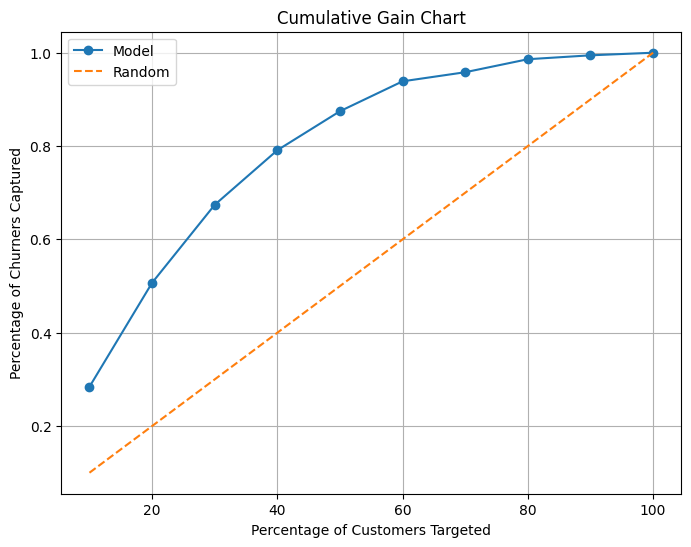

In [ ]:

plt.figure(figsize=(8,6))

# model gain
plt.plot(
    gain_lift_pd["decile"] * 10,
    gain_lift_pd["gain"],
    marker="o",
    label="Model"
)

# random baseline
plt.plot(
    gain_lift_pd["decile"] * 10,
    gain_lift_pd["decile"] / 10,
    linestyle="--",
    label="Random"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Percentage of Churners Captured")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

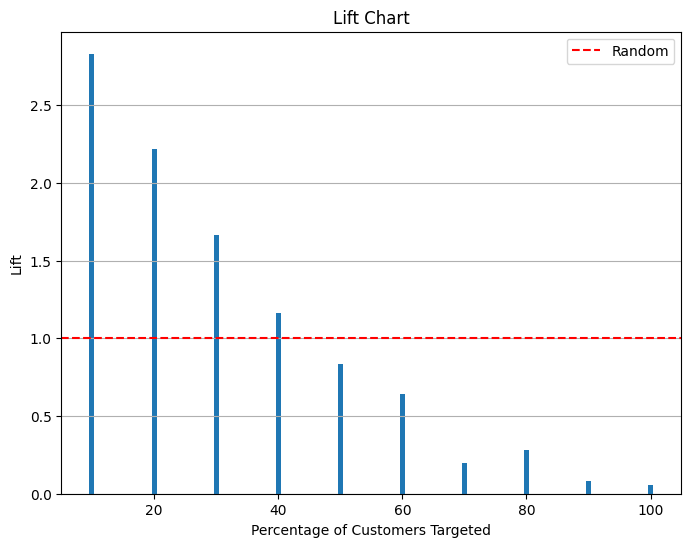

In [ ]:
plt.figure(figsize=(8,6))

plt.bar(
    gain_lift_pd["decile"] * 10,
    gain_lift_pd["lift"]
)

plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    label="Random"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.legend()
plt.grid(axis="y")
plt.show()